# Quantum Social Network Analysis of Judicial Centrality using Grover's Algorithm

This notebook aims to apply **quantum social network analysis (QSNA)** to **the field of law**. 

- I designed this notebook to combine classical graph theory with quantum computing. 
- I model a simplified judicial hierarchy as a directed graph and calculate **degree centrality** to identify the most influential court. 
- To search for the central node, I employ Grover's Search Algorithm (Grover's Algorithm) - a quantum algorithm that amplifies the probability of a target state in an unsorted search space, achieving a quadratic speedup over classical search.  

In this notebook, I focused on the question **"Which court is the most central in the judicial network?"**

### Importing required libraries for graph analysis, visualization, and quantum simulation

**NetworkX** is a Python library for building and studying complex networks. In this notebook, it is used to model the judicial hierarchy as a directed graph and compute degree centrality.

**Matplotlib** is a Python library for creating static and interactive 
visualizations. In this notebook, it is used to visualize circuits, a judicial network graph, and a measurement histogram.

**Qiskit** is a library for programming quantum computers. In this notebook, it is used to construct a quantum circuit and apply Grover's Search Algorithm on the circuit.

In [1]:
# NetworkX library for constructing graph structures 
import networkx as nx

# Matplotlib for visualizing graphs
import matplotlib.pyplot as plt

# QuantumCircuit module for creating quantum circuits
from qiskit import QuantumCircuit

# Aer simulator backend for executing quantum circuits
from qiskit_aer import Aer

# Histogram visualization for measurement outcomes
from qiskit.visualization import plot_histogram 

**Directed graphs** are graphs that consist of nodes with directed edges. In the field of law, we can use those graphs. Because in a simplified legal model, there is a flow from the lower courts to the higher courts.

**Degree centrality** counts how many directed edges point to a node and normalizes this value by dividing it by the maximum possible number of connections. In this graph, we expect that the Supreme Court has the highest degree centrality, as there are three courts - the Constitutional Court, the Council of State, and the First Instance Court - and all have directed edges pointing to it.

In [2]:
# Construct a directed graph
G = nx.DiGraph()

# Add courts as nodes
G.add_node("Constitutional Court")
G.add_node("Supreme Court")
G.add_node("Council of State")
G.add_node("First Instance Court")

# Add directed legal relations between courts as edges

# First Instance Court -> Supreme Court:
G.add_edge("First Instance Court", "Supreme Court")

# Constitutional Court -> Supreme Court:
G.add_edge("Constitutional Court", "Supreme Court")

# Council of State -> Supreme Court:
G.add_edge("Council of State", "Supreme Court")

# Calculate the degree centrality
degree_centrality = nx.in_degree_centrality(G)

# Print centrality results
print("Degree Centrality Results: ")
print(degree_centrality)

Degree Centrality Results: 
{'Constitutional Court': 0.0, 'Supreme Court': 1.0, 'Council of State': 0.0, 'First Instance Court': 0.0}


The cell below helps to **visualize our graph**. There is also a **graph coloring operation**. The Supreme Court is colored purple to distinguish it as the most central node. Other courts are shown in red.

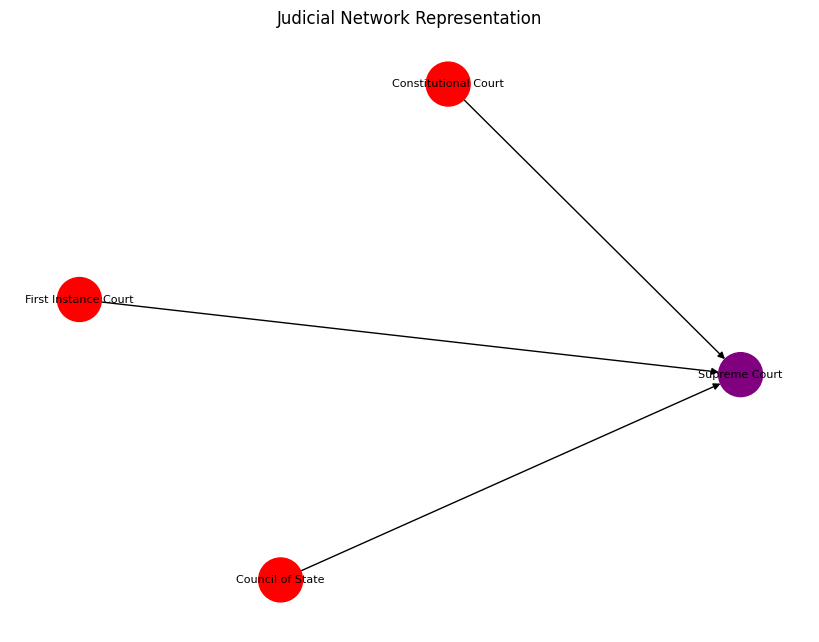

In [3]:
# Define node positions for visualization
pos = nx.spring_layout(G, seed = 42)

# Create a color list for each node
colors = []

# Colors: Supreme Court -> purple, other courts -> red
for node in G.nodes():
    if node == "Supreme Court":
        colors.append("purple")
    else:
        colors.append("red")
# Set figure size
plt.figure(figsize = (8, 6))

# Draw the network
nx.draw(G, with_labels = True, pos = pos, node_size = 1000, font_size = 8, node_color = colors)

# Add title
plt.title("Judicial Network Representation")

# Display graph
plt.show()

Grover's Algorithm, as I mentioned above, achieves a quadratic speedup over classical search. But how does it realise this quadratic speedup?
Grover's Algorithm takes two main steps: 
1. Oracle step: The oracle is the quantum circuit that has a gate application flow like this: (Note: Before the oracle step, we apply Hadamard gate to create a superposition.)
   **X gate --> CZ gate --> X gate** --> With these circuit steps, for a two-qubit quantum circuit that is positioned in a superposition state before, the sign of the marked quantum state is going to flip. 


   a. First of all, the X gate is going to be applied to the qubit in the 0 position.


   b. Secondly, the CZ gate is going to be applied to the quantum state with qubits both in 1 position. By this move, the sign of the marked state is going to change the phase of the marked state will be flipped.


   c. At the end of the oracle, the X gate is going to be applied again to the qubit that had been applied the first X gate before, and we gain the main version of the marked state with a flipped sign.


2. Diffusion step: In short, the duty of the diffusion operator is inversion about the mean. We apply these gates in this order: **Hadamard gate --> X gate --> CZ gate --> X gate --> Hadamard gate**. With the application of these gates, there is going to be an amplification of the amplitudes of quantum states, and with the repetition of the diffusion step, the amplitude of the marked state is going to be the highest one, and we can find out which state is the marked one.

NOTE: In this notebook, the oracle marks the state |10⟩. This state represents the Supreme Court.

| Qubit State | Court |
|-------------|-------|
| \|00⟩ | First Instance Court |
| \|01⟩ | Council of State |
| \|10⟩ | Supreme Court |
| \|11⟩ | Constitutional Court |

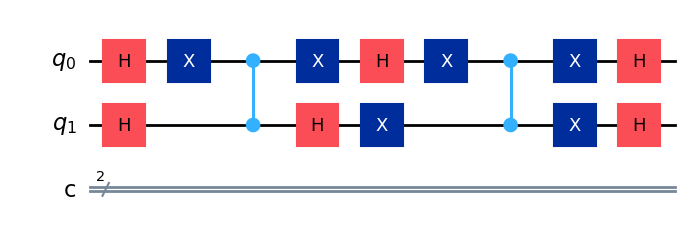

In [4]:
# Quantum circuit with two qubits and two classical bits
circuit = QuantumCircuit(2, 2)

# # Apply Hadamard gates to create superposition
circuit.h([0,1])

# # Define oracle to mark the target state
oracle = QuantumCircuit(2, 2)

oracle.x(0)
oracle.cz(0,1)
oracle.x(0)

# Append oracle
circuit = circuit.compose(oracle)

# Diffusion operator (inversion about the mean)
circuit.h([0, 1])
circuit.x([0, 1])
circuit.cz(0,1)
circuit.x([0, 1])
circuit.h([0, 1])

# Visualize circuit
circuit.draw("mpl")

At this point, we are going to make a **measurement**. The result we expected is {'10': 1024}. This means qubit 1 = 1 and qubit 0 = 0, and the state is $|10\rangle$ (While we enumerate qubits in Qiskit, we start from the right, and for the scenario given in our notebook, the label on the far right qubit is going to take 0). Here, the state $|10\rangle$ represents the Supreme Court. In the law field, this means **the Supreme Court has the highest degree centrality score**. So, the Supreme Court is the node that has the most directed edges pointed to itself.

For Grover's Algorithm, only one iteration is enough to get our target state. Because the number of necessary iterations for the algorithm is equal to $k \approx \frac{\pi}{4} \sqrt{N}$. So, $k = \frac{\pi}{4} \times \sqrt{4} = \frac{\pi}{4} \times 2 \approx 1.57$. In this simulation, the circuit was run 1024 times (shots). All 1024 shots yielded $|10\rangle$ because one iteration is sufficient to reach 100% probability for this system. For two qubits and four states (in a superposition, two qubits create four states because n qubits create $2^n$ states in a superposition state), one iteration makes the amplitude of the marked state 1.  Also, the possibility of get the marked state equals to one (We find probabilities with the square of the absolute value of amplitudes of states).

As a note, we used a simulator. Because of that, we get a certain result with the 100% possibility. But real quantum computers have **noise**, which means they are affected by the environmental conditions (such as temperature). These conditions also affect measurement results.

In [5]:
# Simulation

# Measure
circuit.measure([0, 1], [0, 1])

# Simulator backend
backend = Aer.get_backend("qasm_simulator")

# Execute
job = backend.run(circuit, shots = 1024)

# Results
result = job.result()
counts = result.get_counts(circuit)

print("Measurement Counts: ")
print(counts)

Measurement Counts: 
{'10': 1024}


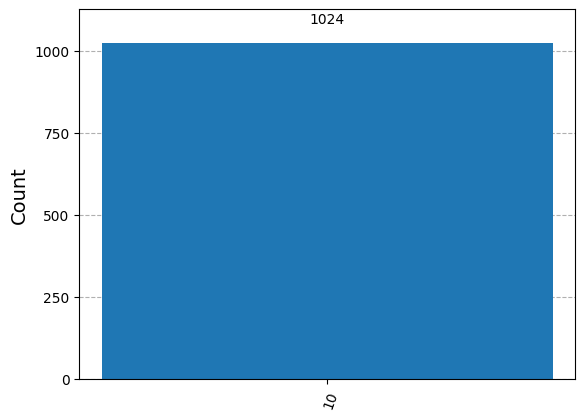

In [6]:
# Histogram of quantum outcomes
plot_histogram(counts)

The code given below was created by Claude Sonnet 4.6 Extended for better visualization of the notebook and its result. 

✓ results.png saved


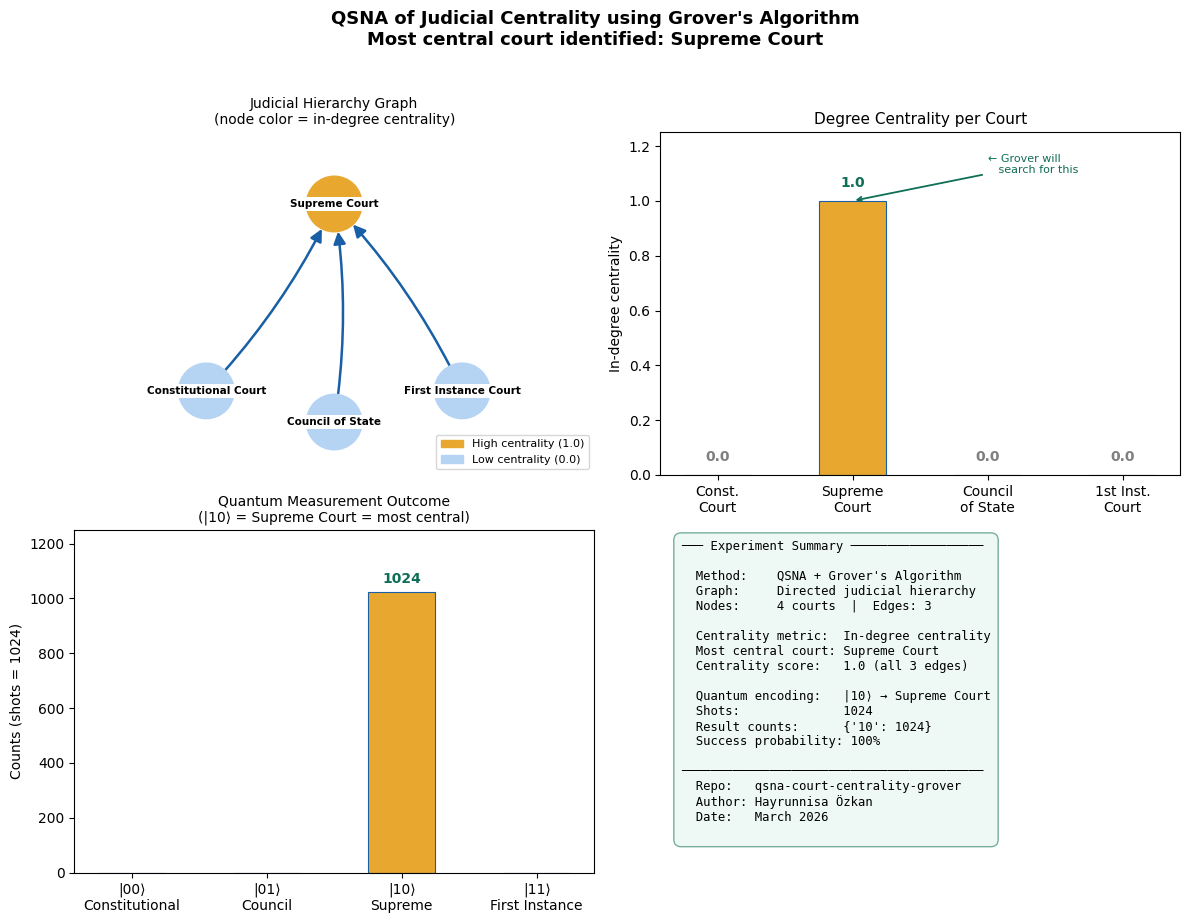

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np

# ── Reconstruct the graph (you can also reuse the G variable from the notebook) ──
G = nx.DiGraph()
courts = ["Constitutional Court", "Supreme Court", "Council of State", "First Instance Court"]
G.add_nodes_from(courts)
G.add_edge("First Instance Court",  "Supreme Court")
G.add_edge("Constitutional Court",  "Supreme Court")
G.add_edge("Council of State",      "Supreme Court")
degree_centrality = nx.in_degree_centrality(G)

# ── Qubit → court mapping (following the order in the notebook) ───────────────
# |00⟩=0, |01⟩=1, |10⟩=2, |11⟩=3
# Notebook code: Supreme Court → index 2 → |10⟩
qubit_to_court = {
    "00": "Constitutional Court",
    "01": "Council of State",
    "10": "Supreme Court",
    "11": "First Instance Court",
}
# Quantum simulation result (taken from the notebook)
counts = {"10": 1024}

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    "QSNA of Judicial Centrality using Grover's Algorithm\n"
    "Most central court identified: Supreme Court",
    fontsize=13, fontweight="bold", y=1.02
)

# ── Panel 1: Judicial network graph ────────────────────────────────────────
ax1 = axes[0, 0]
pos = {
    "Supreme Court":        (0.5,  0.82),
    "Constitutional Court": (0.18, 0.22),   
    "Council of State":     (0.5,  0.12),
    "First Instance Court": (0.82, 0.22),   
}
cent_vals = [degree_centrality[n] for n in courts]
node_colors = ["#E8A830" if v == 1.0 else "#B5D4F4" for v in cent_vals]

nx.draw_networkx(
    G, pos=pos, ax=ax1,
    node_color=node_colors, node_size=1600,
    edge_color=["#185FA5"]*len(G.edges()), arrows=True,
    arrowsize=18, width=1.8,
    font_size=7.5, font_weight="bold",
    connectionstyle="arc3,rad=0.08",
    bbox=dict(fc="white", ec="none", pad=1.5)   # ← etiket arka planı
)
ax1.set_title("Judicial Hierarchy Graph\n(node color = in-degree centrality)", fontsize=10)
ax1.axis("off")

# Expand the visible axis area — prevents labels from being clipped
ax1.set_xlim(-0.15, 1.15)
ax1.set_ylim(-0.05, 1.05)

patch_high = mpatches.Patch(color="#E8A830", label="High centrality (1.0)")
patch_low  = mpatches.Patch(color="#B5D4F4", label="Low centrality (0.0)")
ax1.legend(handles=[patch_high, patch_low], fontsize=8,
           loc="lower right", bbox_to_anchor=(1.0, 0.0))

# ── Panel 2: Centrality bar chart ──────────────────────────────────────────
ax2 = axes[0, 1]
short_names = ["Const.\nCourt", "Supreme\nCourt", "Council\nof State", "1st Inst.\nCourt"]
colors2 = ["#B5D4F4", "#E8A830", "#B5D4F4", "#B5D4F4"]
bars = ax2.bar(short_names, cent_vals, color=colors2,
               edgecolor="#185FA5", linewidth=0.8, width=0.5)
ax2.set_ylabel("In-degree centrality")
ax2.set_title("Degree Centrality per Court", fontsize=11)
ax2.set_ylim(0, 1.25)
for bar, val in zip(bars, cent_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f"{val:.1f}", ha="center", va="bottom", fontsize=10,
             fontweight="bold", color="#0F6E56" if val == 1.0 else "gray")
ax2.annotate("← Grover will\n   search for this",
             xy=(1, 1.0), xytext=(2.0, 1.1),
             arrowprops=dict(arrowstyle="->", color="#0F6E56", lw=1.3),
             fontsize=8, color="#0F6E56")

# ── Panel 3: Quantum measurement histogram (court-labeled) ─────────────────
ax3 = axes[1, 0]
all_states = ["00", "01", "10", "11"]
meas_vals  = [counts.get(s, 0) for s in all_states]
xlabels    = [f"|{s}⟩\n{qubit_to_court[s].replace(' Court','').replace(' of State','')}"
              for s in all_states]
colors3    = ["#E8A830" if s == "10" else "#B5D4F4" for s in all_states]
bars3 = ax3.bar(xlabels, meas_vals, color=colors3,
                edgecolor="#185FA5", linewidth=0.8, width=0.5)
ax3.set_ylabel("Counts (shots = 1024)")
ax3.set_title("Quantum Measurement Outcome\n(|10⟩ = Supreme Court = most central)", fontsize=10)
ax3.set_ylim(0, 1250)
for bar, val in zip(bars3, meas_vals):
    if val > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, val + 20,
                 str(val), ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#0F6E56")

# ── Panel 4: Summary ───────────────────────────────────────────────────────
ax4 = axes[1, 1]
ax4.axis("off")
summary = (
    "─── Experiment Summary ──────────────────\n\n"
    "  Method:    QSNA + Grover's Algorithm\n"
    "  Graph:     Directed judicial hierarchy\n"
    "  Nodes:     4 courts  |  Edges: 3\n\n"
    "  Centrality metric:  In-degree centrality\n"
    "  Most central court: Supreme Court\n"
    "  Centrality score:   1.0 (all 3 edges)\n\n"
    "  Quantum encoding:   |10⟩ → Supreme Court\n"
    "  Shots:              1024\n"
    "  Result counts:      {'10': 1024}\n"
    "  Success probability: 100%\n\n"
    "─────────────────────────────────────────\n"
    "  Repo:   qsna-court-centrality-grover\n"
    "  Author: Hayrunnisa Özkan\n"
    "  Date:   March 2026\n"
)
ax4.text(0.04, 0.97, summary, transform=ax4.transAxes,
         fontsize=8.8, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#E1F5EE",
                   edgecolor="#0F6E56", alpha=0.55))

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches="tight")
print("✓ results.png saved")
plt.show()

In [8]:
# Python version
!python --version > environment_info.txt

In [9]:
# Qiskit, Qiskit-Aer, NetworkX, Matplotlib and NumPy versions
!pip show qiskit qiskit-aer networkx matplotlib numpy >> environment_info.txt

### There would be some future extensions. These may include:
- **Precedent Graphs:** Courts refer to precedents while settling cases. We can model these citation networks as a graph. Modeling these citation networks as a graph would allow QSNA techniques to identify the most influential precedents.
- **Quantum-assisted Legal Analytics:** Quantum algorithms could be applied to wider and more complex data sets, such as analyzing case decisions.

**Sources:**

https://networkx.org/en/

https://matplotlib.org

https://pennylane.ai/qml/glossary/what-is-qiskit

https://networkx.org/documentation/stable/reference/introduction.html

https://claude.ai/